# House Price Prediction using Linear Regression (Step by Step)

# House Price Prediction using Linear Regression

## Objective
In this notebook, we will apply **Linear Regression step by step** to predict house prices using the **California Housing dataset**.

We will:
- load and prepare the dataset
- split the data into training, validation, and test sets
- train a Linear Regression model
- make predictions
- evaluate the model using:
  - MSE
  - RMSE
  - MAE
  - R² Score
- apply cross-validation
- visualize the results

This notebook is designed to help understand both the **practical steps** and the **intuition behind Linear Regression**.

# Import libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Charger le dataset

In [78]:
df = pd.read_csv("housing_cleaned.csv")

df.head()

print("/n")

df.tail()

print("Voir la taille")

df.shape

print("Voir les colonnes")

df.columns

print("Voir les types de colonnes")

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

/n
Voir la taille
Voir les colonnes
Voir les types de colonnes
<class 'pandas.DataFrame'>
RangeIndex: 16683 entries, 0 to 16682
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16683 non-null  float64
 1   latitude            16683 non-null  float64
 2   housing_median_age  16683 non-null  float64
 3   total_rooms         16683 non-null  float64
 4   total_bedrooms      16683 non-null  float64
 5   population          16683 non-null  float64
 6   households          16683 non-null  float64
 7   median_income       16683 non-null  float64
 8   median_house_value  16683 non-null  float64
 9   ocean_proximity     16683 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.3 MB


np.int64(0)

# Définir la target et les features

In [79]:
y = df ["median_house_value"]

print("y shape" , y.shape)



X = df.drop("median_house_value", axis=1)

print("X shape" , X.shape)

y shape (16683,)
X shape (16683, 9)


# Encoder la variable catégorielle

In [80]:
X = pd.get_dummies(X , drop_first=True)

print("Verify the columns")

df.head()

df.shape

Verify the columns


(16683, 10)

# Step 1 : Split Train / Validation / Test

In [81]:
X_train , X_temp , y_train , y_temp = train_test_split(
    X ,y , test_size=0.30 , random_state=42
)

# Step 2 : Validation + Test

In [82]:
X_val , X_test , y_val , y_test = train_test_split(
    X_temp ,y_temp , test_size=0.50 , random_state=42
)

# Step 3 : Verify the shaape of the splits

In [83]:
print("Train shape      :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Test shape       :", X_test.shape)

Train shape      : (11678, 12)
Validation shape : (2502, 12)
Test shape       : (2503, 12)


# Step 4 : Data standardization

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.fit_transform(X_test)



# Linear Regression Intuition

Linear Regression is a supervised learning algorithm that models the **linear relationship** between input features and a target variable.

---

## Simple Linear Regression

When we have **only one input feature**, the relationship is represented by a straight line:

$$
\hat{y} = ax + b
$$

| Symbol | Meaning |
|--------|---------|
| $x$ | Input feature (independent variable) |
| $a$ | Slope — how much $y$ changes per unit change in $x$ |
| $b$ | Intercept — the value of $\hat{y}$ when $x = 0$ |
| $\hat{y}$ | Predicted value (pronounced "y-hat") |

Think of it as: draw the best straight line through your data points.

---

## Multiple Linear Regression

In real-world problems, we usually have **multiple features**. The formula extends to:

$$
\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$

| Symbol | Meaning |
|--------|---------|
| $x_1, x_2, \dots, x_n$ | Input features |
| $w_1, w_2, \dots, w_n$ | Weights (coefficients) — one per feature |
| $b$ | Bias (intercept) |

The model learns the **optimal values** for $w_1, w_2, \dots, w_n$ and $b$ during training.

---

## What Does "Learning" Mean?

The model finds the coefficients that **minimize the error** between predicted values $\hat{y}$ and actual values $y$.  
A common way to measure this error is using **Mean Squared Error (MSE)**:

$$
\text{MSE} = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2
$$

Where $m$ is the number of training examples.

---

## Key Takeaway

Linear Regression is simple, interpretable, and a great starting point for understanding how models learn patterns from data.

# Error and Loss Function

For each prediction, the error is the difference between the actual value and the predicted value:

$$
\text{error} = y - \hat{y}
$$

To evaluate the model globally, we use a **loss function**. The loss function aggregates the errors across all training examples to give a single measure of model performance.

---

## Mean Squared Error (MSE)

The most common loss function for Linear Regression is the **Mean Squared Error**:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Where:
- $n$ = number of training examples
- $y_i$ = actual value of the $i$-th example
- $\hat{y}_i$ = predicted value of the $i$-th example

---

## Why Square the Error?

Squaring the errors serves three purposes:

1. **Removes sign** — positive and negative errors don't cancel each other out
2. **Penalizes large errors more heavily** — larger differences have a bigger impact
3. **Makes the function differentiable** — important for optimization algorithms

---

## Goal of Training

The model learns by finding the coefficients $w_1, w_2, \dots, w_n$ and $b$ that **minimize** the MSE:

$$
\min_{w, b} \frac{1}{n} \sum_{i=1}^{n} (y_i - (w_1 x_{i1} + w_2 x_{i2} + \cdots + w_n x_{in} + b))^2
$$

This is achieved through optimization algorithms like **Gradient Descent** or solved directly using the **Normal Equation**.

---

## Key Takeaway

The loss function is the compass that guides the model during training. Lower loss = better predictions.

# Step 5 : Convert Target to NumPy Arrays

In [85]:
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

# Step 6 : Initialize Model Parameters

In [86]:
# Number of features
n_features = X_train_scaled.shape[1]

# Initialize weights and bias
np.random.seed(42)
weights = np.random.randn(n_features) * 0.01
bias = 0.0

print(f"Number of features: {n_features}")
print(f"Initial weights shape: {weights.shape}")
print(f"Initial bias: {bias}")

Number of features: 12
Initial weights shape: (12,)
Initial bias: 0.0


# Step 7 : Define the Prediction Function

In [87]:
def predict(X, weights, bias):
    return np.dot(X, weights) + bias

# Step 8 : Test the Prediction Function

In [88]:
# Test prediction on first 5 samples
y_pred_test = predict(X_train_scaled[:5], weights, bias)
print("First 5 predictions:", y_pred_test)
print("First 5 actual values:", y_train[:5])

First 5 predictions: [-0.01074375 -0.0110169  -0.02289671 -0.05113549  0.04543626]
First 5 actual values: [209800.  84700.  64800.  58800. 329100.]


# Step 9 : Define the Error Function

In [89]:
def compute_error(y_true, y_pred):
    return y_true - y_pred

# Step 10 : Test the Error Function

In [90]:
# Test error function
error_test = compute_error(y_train[:5], y_pred_test)
print("Errors for first 5 samples:", error_test)

Errors for first 5 samples: [209800.01074375  84700.0110169   64800.02289671  58800.05113549
 329099.95456374]


# Step 11 : Define the Loss Function (MSE)

In [91]:
def compute_mse(y_true, y_pred):
    
    errors = y_true - y_pred
    squared_errors = errors ** 2
    mse = np.mean(squared_errors)
    return mse

# Step 12 : Test the Loss Function

In [92]:
# Test MSE function
mse_test = compute_mse(y_train[:5], y_pred_test)
print(f"MSE on first 5 samples: {mse_test:.2f}")

MSE on first 5 samples: 33430681089.83


# Step 13 : Explain the Loss Function

"""
Mean Squared Error (MSE) Explanation:

MSE = (1/n) * Σ(y_i - ŷ_i)²

Why we use MSE:
1.  Penalizes large errors more heavily (squaring gives more weight to outliers)
2.  Differentiable, allowing gradient descent optimization
3.  Always positive, so minimizing it makes sense

The model learns by finding weights and bias that MINIMIZE this MSE value.
Lower MSE = Better predictions!
"""

# Step 14 : Gradient Descent - Define the Gradient Computation

In [93]:
def compute_gradients(X, y_true, y_pred):
    
    n_samples = len(y_true)
    errors = y_pred - y_true  # Note: (pred - true) for gradient descent
    
    # Gradient for weights
    dw = (2 / n_samples) * np.dot(X.T, errors)
    
    # Gradient for bias
    db = (2 / n_samples) * np.sum(errors)
    
    return dw, db

# Step 15 : Test the Gradient Function

In [94]:
# Test gradient computation
y_pred_sample = predict(X_train_scaled[:100], weights, bias)
dw_test, db_test = compute_gradients(X_train_scaled[:100], y_train[:100], y_pred_sample)
print(f"Gradient for first weight: {dw_test[0]:.6f}")
print(f"Gradient for bias: {db_test:.6f}")

Gradient for first weight: 32905.222462
Gradient for bias: -338370.011537


# Step 17 : Set Hyperparameters

In [95]:
# Hyperparameters
learning_rate = 0.01
n_epochs = 500

# To store loss history
train_losses = []
val_losses = []

print(f"Learning rate: {learning_rate}")
print(f"Number of epochs: {n_epochs}")

Learning rate: 0.01
Number of epochs: 500


# Step 18 : Model Training - Train using Gradient Descent

In [96]:
# Initialize weights and bias
np.random.seed(42)
weights = np.random.randn(n_features) * 0.01
bias = 0.0

# Training loop
for epoch in range(n_epochs):
    # Forward pass - make predictions
    y_train_pred = predict(X_train_scaled, weights, bias)
    y_val_pred = predict(X_val_scaled, weights, bias)
    
    # Calculate losses
    train_loss = compute_mse(y_train, y_train_pred)
    val_loss = compute_mse(y_val, y_val_pred)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Backward pass - compute gradients
    dw, db = compute_gradients(X_train_scaled, y_train, y_train_pred)
    
    # Update parameters
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db
    
    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {train_loss:.2f}, Val Loss: {val_loss:.2f}")

print("\n Training completed!")

Epoch 50/500 - Train Loss: 8617644264.29, Val Loss: 8687558362.25
Epoch 100/500 - Train Loss: 4128448073.62, Val Loss: 4180791307.55
Epoch 150/500 - Train Loss: 3484698200.14, Val Loss: 3535017922.93
Epoch 200/500 - Train Loss: 3357872041.23, Val Loss: 3410536442.62
Epoch 250/500 - Train Loss: 3310639352.55, Val Loss: 3366661619.28
Epoch 300/500 - Train Loss: 3281354133.46, Val Loss: 3340685951.28
Epoch 350/500 - Train Loss: 3259447904.77, Val Loss: 3321778848.19
Epoch 400/500 - Train Loss: 3242043155.87, Val Loss: 3307040574.13
Epoch 450/500 - Train Loss: 3227804961.97, Val Loss: 3295170738.88
Epoch 500/500 - Train Loss: 3215915351.06, Val Loss: 3285391838.41

 Training completed!


# Step 19 : Display Final Parameters

In [97]:
print("\n Final Model Parameters:")
print(f"Bias: {bias:.4f}")
print(f"Weights shape: {weights.shape}")
print("\nFirst 10 weights:")
for i, w in enumerate(weights[:10]):
    print(f"  Feature {i}: {w:.4f}")


 Final Model Parameters:
Bias: 184458.5309
Weights shape: (12,)

First 10 weights:
  Feature 0: -16656.9812
  Feature 1: -15416.2807
  Feature 2: 10699.9892
  Feature 3: 876.4117
  Feature 4: 16403.4989
  Feature 5: -29806.0972
  Feature 6: 16222.5924
  Feature 7: 50682.6110
  Feature 8: -28837.8507
  Feature 9: 3742.5992


# Step 20 : Plot the Loss Curve

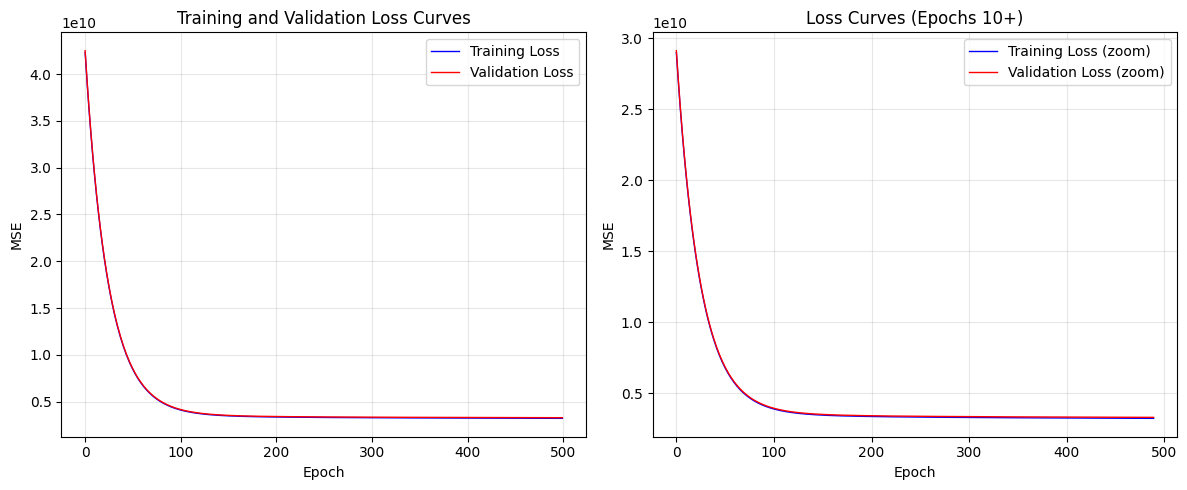


Final Training MSE: 3215915351.06
Final Validation MSE: 3285391838.41


In [98]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=1)
plt.plot(val_losses, label='Validation Loss', color='red', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses[10:], label='Training Loss (zoom)', color='blue', linewidth=1)
plt.plot(val_losses[10:], label='Validation Loss (zoom)', color='red', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Loss Curves (Epochs 10+)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training MSE: {train_losses[-1]:.2f}")
print(f"Final Validation MSE: {val_losses[-1]:.2f}")

# Step 21 : Make Predictions

In [99]:
# Make predictions on all sets
y_train_pred_final = predict(X_train_scaled, weights, bias)
y_val_pred_final = predict(X_val_scaled, weights, bias)
y_test_pred_final = predict(X_test_scaled, weights, bias)

print(" Predictions completed!")
print(f"Training predictions shape: {y_train_pred_final.shape}")
print(f"Validation predictions shape: {y_val_pred_final.shape}")
print(f"Test predictions shape: {y_test_pred_final.shape}")

 Predictions completed!
Training predictions shape: (11678,)
Validation predictions shape: (2502,)
Test predictions shape: (2503,)


# Step 22 : Define the Evaluation Function

In [100]:
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
   
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n {dataset_name} Performance:")
    print(f"  MSE  : {mse:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  R²   : {r2:.4f}")
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# Step 23 : Evaluate Training Performance

In [101]:
train_metrics = evaluate_model(y_train, y_train_pred_final, "Training Set")


 Training Set Performance:
  MSE  : 3215697397.14
  RMSE : 56707.12
  MAE  : 42152.67
  R²   : 0.6119


# Step 24 : Evaluate Validation Performance

In [102]:
val_metrics = evaluate_model(y_val, y_val_pred_final, "Validation Set")


 Validation Set Performance:
  MSE  : 3285213724.71
  RMSE : 57316.78
  MAE  : 42585.39
  R²   : 0.6122


# Step 25 : Evaluate Test Performance

In [103]:
test_metrics = evaluate_model(y_test, y_test_pred_final, "Test Set")


 Test Set Performance:
  MSE  : 3180215067.59
  RMSE : 56393.40
  MAE  : 42587.86
  R²   : 0.6226


# Step 26 : Create a Performance Summary Table

In [104]:
# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Training': [train_metrics['MSE'], train_metrics['RMSE'], train_metrics['MAE'], train_metrics['R2']],
    'Validation': [val_metrics['MSE'], val_metrics['RMSE'], val_metrics['MAE'], val_metrics['R2']],
    'Test': [test_metrics['MSE'], test_metrics['RMSE'], test_metrics['MAE'], test_metrics['R2']]
})

print("\n Model Performance Summary")
print("=" * 60)
print(summary_df.to_string(index=False))


 Model Performance Summary
Metric     Training   Validation         Test
   MSE 3.215697e+09 3.285214e+09 3.180215e+09
  RMSE 5.670712e+04 5.731678e+04 5.639340e+04
   MAE 4.215267e+04 4.258539e+04 4.258786e+04
    R² 6.118785e-01 6.121550e-01 6.226027e-01


# Step 27 : Metrics Interpretation

print("""
 Metrics Interpretation:

1. MSE (Mean Squared Error):
   - Average squared difference between predictions and actual values
   - Lower is better
   - Sensitive to outliers due to squaring

2. RMSE (Root Mean Squared Error):
   - Square root of MSE, in same units as target variable
   - More interpretable than MSE
   - Lower is better

3. MAE (Mean Absolute Error):
   - Average absolute difference between predictions and actual values
   - Less sensitive to outliers than MSE/RMSE
   - Lower is better

4. R² Score (Coefficient of Determination):
   - Proportion of variance explained by the model
   - Range: (-∞, 1]
   - 1 = perfect prediction
   - 0 = model predicts mean
   - Negative = worse than predicting mean

 Our Model Performance:
   - R² Score on Test Set: {:.4f}
   - This means the model explains {:.1f}% of the variance in house prices
   - RMSE on Test Set: ${:.0f}
   - Average prediction error is about ${:.0f}
""".format(
    test_metrics['R2'], 
    test_metrics['R2'] * 100,
    test_metrics['RMSE'],
    test_metrics['MAE']
))

# Step 28 : Cross-Validation - Define Training Function

In [105]:
def train_model_cv(X_train_fold, y_train_fold, X_val_fold, y_val_fold, 
                   learning_rate=0.01, n_epochs=500):
   
    n_features = X_train_fold.shape[1]
    np.random.seed(42)
    weights = np.random.randn(n_features) * 0.01
    bias = 0.0
    
    for epoch in range(n_epochs):
        y_pred = predict(X_train_fold, weights, bias)
        dw, db = compute_gradients(X_train_fold, y_train_fold, y_pred)
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
    
    # Evaluate on validation fold
    y_val_pred = predict(X_val_fold, weights, bias)
    val_mse = compute_mse(y_val_fold, y_val_pred)
    
    return weights, bias, val_mse

# Step 29 : Perform 5-Fold Cross-Validation

In [106]:
from sklearn.model_selection import KFold

# Prepare full dataset
X_full = np.vstack([X_train_scaled, X_val_scaled, X_test_scaled])
y_full = np.concatenate([y_train, y_val, y_test])

print(f"Full dataset shape: {X_full.shape}")

# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

fold = 1
for train_idx, val_idx in kf.split(X_full):
    X_fold_train, X_fold_val = X_full[train_idx], X_full[val_idx]
    y_fold_train, y_fold_val = y_full[train_idx], y_full[val_idx]
    
    _, _, val_mse = train_model_cv(X_fold_train, y_fold_train, 
                                   X_fold_val, y_fold_val)
    cv_scores.append(val_mse)
    
    print(f"Fold {fold}: Validation MSE = {val_mse:.2f}")
    fold += 1

Full dataset shape: (16683, 12)
Fold 1: Validation MSE = 3301316291.97
Fold 2: Validation MSE = 3069116827.93
Fold 3: Validation MSE = 3267185374.69
Fold 4: Validation MSE = 3395567530.62
Fold 5: Validation MSE = 3110019269.75


# Step 30 : Display Cross-Validation Results

In [107]:
print("\n Cross-Validation Results")
print("=" * 50)
print(f"Individual fold MSE scores: {[f'{score:.2f}' for score in cv_scores]}")
print(f"Mean MSE: {np.mean(cv_scores):.2f}")
print(f"Std MSE: {np.std(cv_scores):.2f}")
print(f"Mean RMSE: {np.sqrt(np.mean(cv_scores)):.2f}")

print("\n Interpretation:")
print("  - Cross-validation helps ensure model generalizes well")
print("  - Low variance between folds indicates stable performance")
print(f"  - 5-fold CV MSE: {np.mean(cv_scores):.2f} ± {np.std(cv_scores):.2f}")


 Cross-Validation Results
Individual fold MSE scores: ['3301316291.97', '3069116827.93', '3267185374.69', '3395567530.62', '3110019269.75']
Mean MSE: 3228641058.99
Std MSE: 121779234.58
Mean RMSE: 56821.13

 Interpretation:
  - Cross-validation helps ensure model generalizes well
  - Low variance between folds indicates stable performance
  - 5-fold CV MSE: 3228641058.99 ± 121779234.58


# Step 31 : Model Interpretation - Display Learned Coefficients

In [108]:
# Get feature names (after one-hot encoding)
feature_names = X.columns.tolist()

print("\n Feature Coefficients (Model Interpretability)")
print("=" * 70)
print(f"{'Feature':<25} {'Coefficient':>15} {'Impact':>20}")
print("-" * 70)

# Sort by absolute coefficient value
sorted_idx = np.argsort(np.abs(weights))[::-1]

for idx in sorted_idx[:15]:  # Show top 15 most important features
    impact = "Positive" if weights[idx] > 0 else "Negative"
    print(f"{feature_names[idx]:<25} {weights[idx]:>15.4f} {impact:>20}")

print("\nNote: Positive coefficients increase house price, negative decrease it")


 Feature Coefficients (Model Interpretability)
Feature                       Coefficient               Impact
----------------------------------------------------------------------
median_income                  50682.6110             Positive
population                    -29806.0972             Negative
ocean_proximity_inland        -28837.8507             Negative
longitude                     -16656.9812             Negative
total_bedrooms                 16403.4989             Positive
households                     16222.5924             Positive
latitude                      -15416.2807             Negative
housing_median_age             10699.9892             Positive
ocean_proximity_island          3742.5992             Positive
ocean_proximity_near bay       -2422.2205             Negative
ocean_proximity_near ocean       1302.2510             Positive
total_rooms                      876.4117             Positive

Note: Positive coefficients increase house price, negative d

# Step 32 : Interpret Coefficients

In [109]:
print("""
 Coefficient Interpretation:

1. A positive coefficient means:
   - As the feature increases, predicted house price increases
   - Example: If median_income coefficient is positive, higher income = higher price

2. A negative coefficient means:
   - As the feature increases, predicted house price decreases
   - Example: If latitude coefficient is negative, moving north = lower prices

3. Magnitude of coefficient:
   - Larger absolute value = stronger influence on prediction
   - (After standardization, coefficients are comparable across features)

 Key Insights from our model:
""")

# Get top positive and negative features
positive_idx = np.where(weights > 0)[0]
negative_idx = np.where(weights < 0)[0]

if len(positive_idx) > 0:
    top_positive = positive_idx[np.argmax(weights[positive_idx])]
    print(f"   Strongest positive influence: {feature_names[top_positive]}")
    
if len(negative_idx) > 0:
    top_negative = negative_idx[np.argmin(weights[negative_idx])]
    print(f"   Strongest negative influence: {feature_names[top_negative]}")


 Coefficient Interpretation:

1. A positive coefficient means:
   - As the feature increases, predicted house price increases
   - Example: If median_income coefficient is positive, higher income = higher price

2. A negative coefficient means:
   - As the feature increases, predicted house price decreases
   - Example: If latitude coefficient is negative, moving north = lower prices

3. Magnitude of coefficient:
   - Larger absolute value = stronger influence on prediction
   - (After standardization, coefficients are comparable across features)

 Key Insights from our model:

   Strongest positive influence: median_income
   Strongest negative influence: population


# Step 33 : Visualization - Plot True vs Predicted Values

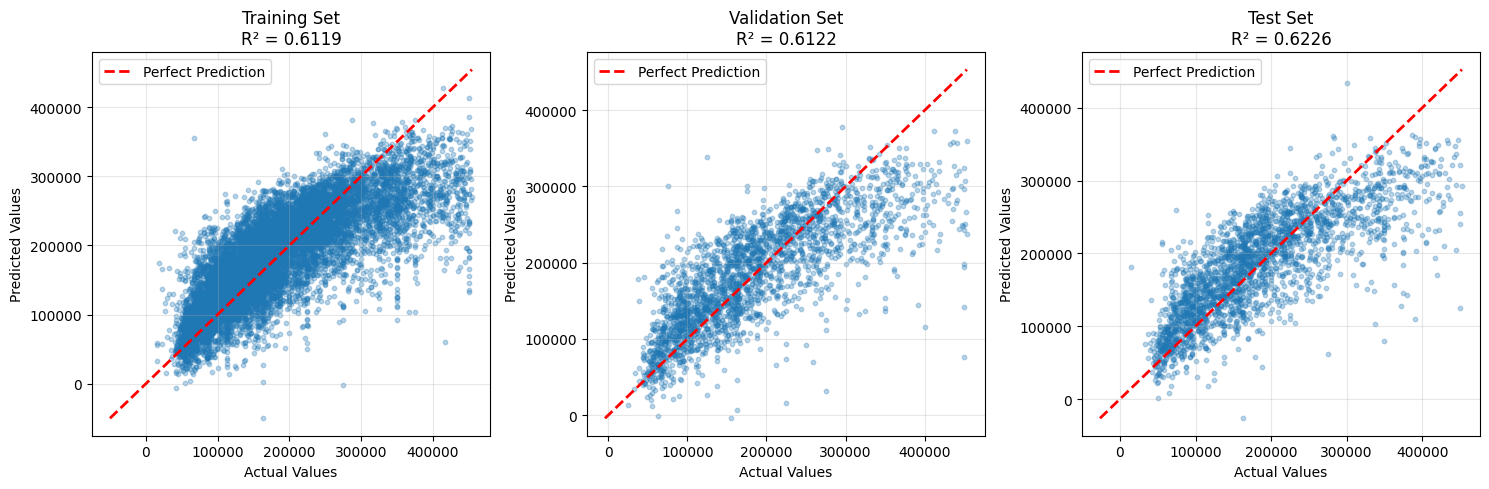

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (y_train, y_train_pred_final, "Training Set"),
    (y_val, y_val_pred_final, "Validation Set"),
    (y_test, y_test_pred_final, "Test Set")
]

for ax, (y_true, y_pred, title) in zip(axes, datasets):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    
    # Plot perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.set_title(f'{title}\nR² = {r2_score(y_true, y_pred):.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 34 : Visualization - Plot Residuals

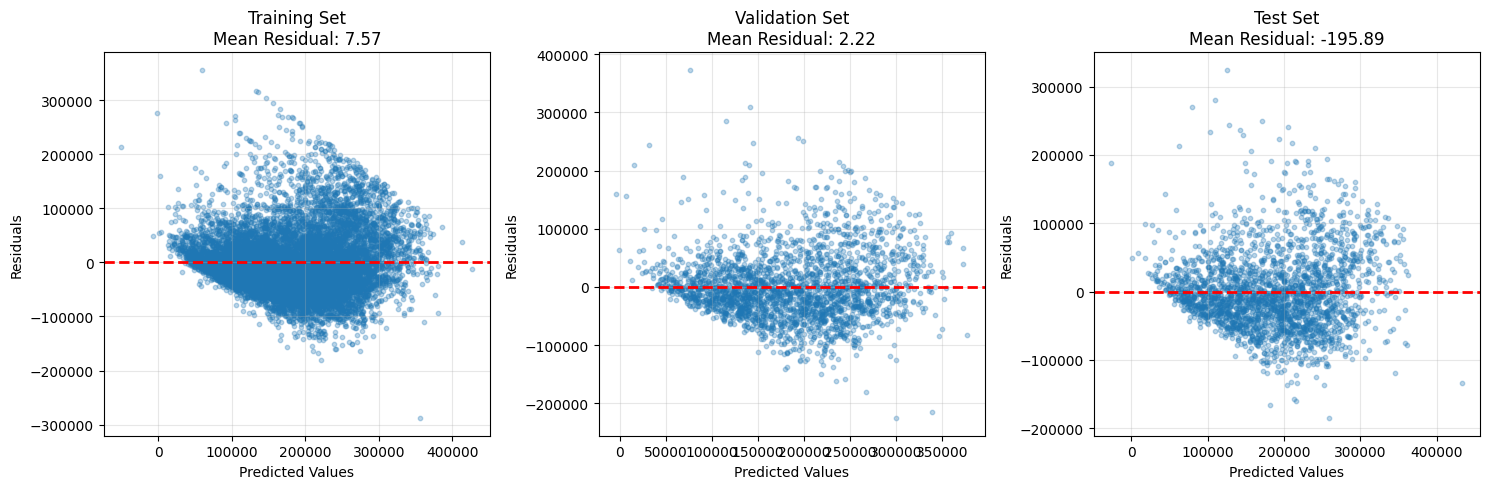


  Residual Plot Interpretation:
  - Random scatter around zero = good model
  - Patterns or trends = model missing something
  - Mean residual close to zero = unbiased predictions
  - Spread should be similar across predicted values (homoscedasticity)



In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (y_train, y_train_pred_final, "Training Set"),
    (y_val, y_val_pred_final, "Validation Set"),
    (y_test, y_test_pred_final, "Test Set")
]

for ax, (y_true, y_pred, title) in zip(axes, datasets):
    residuals = y_true - y_pred
    
    ax.scatter(y_pred, residuals, alpha=0.3, s=10)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{title}\nMean Residual: {np.mean(residuals):.2f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
  Residual Plot Interpretation:
  - Random scatter around zero = good model
  - Patterns or trends = model missing something
  - Mean residual close to zero = unbiased predictions
  - Spread should be similar across predicted values (homoscedasticity)
""")

# Step 35 : Final Conclusion

print("""
 Linear Regression Model - Final Conclusion
===============================================

 Model Performance Summary:
   - R² Score (Test): {:.4f} ({:.1f}% of variance explained)
   - RMSE (Test): ${:.0f}
   - MAE (Test): ${:.0f}

 Strengths:
   - Simple and interpretable
   - Fast training and prediction
   - Provides clear coefficient interpretations
   - Good baseline for more complex models

 Limitations:
   - Assumes linear relationship between features and target
   - Sensitive to outliers
   - May underfit if true relationship is non-linear

 Next Steps to Improve:
   1. Try polynomial features to capture non-linear patterns
   2. Use regularization (Ridge/Lasso) to prevent overfitting
   3. Feature engineering (create interaction terms)
   4. Try more complex models (Decision Trees, Random Forest, XGBoost)
   5. Perform hyperparameter tuning

 Key Takeaways:
   - Linear regression is a great starting point for regression problems
   - Gradient descent efficiently finds optimal parameters
   - Cross-validation helps assess model generalization
   - Understanding coefficients provides business insights
""".format(
    test_metrics['R2'],
    test_metrics['R2'] * 100,
    test_metrics['RMSE'],
    test_metrics['MAE']
))